In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
# List of IT stocks
it_stocks = ['INFY.NS', 'WIPRO.NS', 'TCS.NS', 'HCLTECH.NS', 'TECHM.NS']

# Download historical stock data for the selected IT companies
data = yf.download(it_stocks)

# Flatten multi-level columns to make them easier to work with
data.columns = [f"{col[1]}_{col[0]}" for col in data.columns]

# Print the first few rows of the data to verify
print(data.tail())

[*********************100%***********************]  5 of 5 completed

                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2024-11-29 00:00:00+00:00           1848.050049        1857.849976   
2024-12-02 00:00:00+00:00           1871.500000        1879.800049   
2024-12-03 00:00:00+00:00           1890.750000        1892.099976   
2024-12-04 00:00:00+00:00           1897.650024        1889.250000   
2024-12-05 00:00:00+00:00           1924.000000        1934.849976   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2024-11-29 00:00:00+00:00       4270.850098         1712.300049   
2024-12-02 00:00:00+00:00       4276.649902         1745.949951   
2024-12-03 00:00:00+00:00       4302.750000         1749.500000   
2024-12-04 00:00:00+00:00       4354.399902         1759.599976   
2024-12-05 00:00:00+00:00       4464.049805         1786.949951   

                           WIPRO.NS_Adj

In [3]:
data

,HCLTECH.NS_Adj Close,INFY.NS_Adj Close,TCS.NS_Adj Close,TECHM.NS_Adj Close,WIPRO.NS_Adj Close,HCLTECH.NS_Close,INFY.NS_Close,TCS.NS_Close,TECHM.NS_Close,WIPRO.NS_Close,...,HCLTECH.NS_Open,INFY.NS_Open,TCS.NS_Open,TECHM.NS_Open,WIPRO.NS_Open,HCLTECH.NS_Volume,INFY.NS_Volume,TCS.NS_Volume,TECHM.NS_Volume,WIPRO.NS_Volume
Date,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00+00:00,NaN,0.507060,NaN,NaN,0.415685,NaN,0.796679,NaN,NaN,0.562500,...,NaN,0.794921,NaN,NaN,0.562500,NaN,204800.0,NaN,NaN,39999.0
1996-01-02 00:00:00+00:00,NaN,0.505010,NaN,NaN,0.383354,NaN,0.793457,NaN,NaN,0.518750,...,NaN,0.794921,NaN,NaN,0.518750,NaN,204800.0,NaN,NaN,79999.0
1996-01-03 00:00:00+00:00,NaN,0.508428,NaN,NaN,0.397211,NaN,0.798828,NaN,NaN,0.537500,...,NaN,0.798828,NaN,NaN,0.537500,NaN,102400.0,NaN,NaN,39999.0
1996-01-04 00:00:00+00:00,NaN,0.505071,NaN,NaN,0.397211,NaN,0.793554,NaN,NaN,0.537500,...,NaN,0.791015,NaN,NaN,0.537500,NaN,307200.0,NaN,NaN,239999.0
1996-01-05 00:00:00+00:00,NaN,0.499105,NaN,NaN,0.397211,NaN,0.784179,NaN,NaN,0.537500,...,NaN,0.784179,NaN,NaN,0.537500,NaN,51200.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-29 00:00:00+00:00,1848.050049,1857.849976,4270.850098,1712.300049,288.924988,1848.050049,1857.849976,4270.850098,1712.300049,288.924988,...,1842.000000,1851.099976,4220.000000,1708.000000,287.500000,2482280.0,5244346.0,2017425.0,1556942.0,8540112.0
2024-12-02 00:00:00+00:00,1871.500000,1879.800049,4276.649902,1745.949951,292.274994,1871.500000,1879.800049,4276.649902,1745.949951,292.274994,...,1848.050049,1859.000000,4270.000000,1710.000000,291.225006,2014744.0,2868263.0,1670944.0,1370756.0,11194000.0
2024-12-03 00:00:00+00:00,1890.750000,1892.099976,4302.750000,1749.500000,291.649994,1890.750000,1892.099976,4302.750000,1749.500000,291.649994,...,1884.000000,1887.000000,4314.350098,1760.000000,295.350006,2954648.0,4715792.0,2010905.0,1824151.0,15445286.0


In [26]:
# Identify the first available data date for each stock
start_dates = {}
for ticker in it_stocks:
    adj_close_column = f"{ticker}_Adj Close"
    first_valid_date = data[adj_close_column].dropna().index[0]
    start_dates[ticker] = first_valid_date

# Print start dates for each stock
print("\nStart dates for each stock:")
for ticker, start_date in start_dates.items():
    print(f"{ticker}: {start_date}")

# Filter the data to keep only the valid rows for each stock
valid_data = data.copy()
for ticker in it_stocks:
    start_date = start_dates[ticker]
    adj_close_column = f"{ticker}_Adj Close"
    valid_data = valid_data.loc[valid_data.index >= start_date]

# Print the filtered data
print("\nFiltered Data:")
print(valid_data.tail())


Start dates for each stock:
INFY.NS: 1996-01-01 00:00:00+00:00
WIPRO.NS: 1996-01-01 00:00:00+00:00
TCS.NS: 2002-08-12 00:00:00+00:00
HCLTECH.NS: 2002-08-12 00:00:00+00:00
TECHM.NS: 2006-08-28 00:00:00+00:00

Filtered Data:
                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2024-11-13 00:00:00+00:00           1864.750000        1868.400024   
2024-11-14 00:00:00+00:00           1858.949951        1864.550049   
2024-11-18 00:00:00+00:00           1835.000000        1811.449951   
2024-11-19 00:00:00+00:00           1820.550049        1824.750000   
2024-11-21 00:00:00+00:00           1836.349976        1834.050049   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2024-11-13 00:00:00+00:00       4150.350098         1675.599976   
2024-11-14 00:00:00+00:00       4145.899902         1687.500000   
2024-11-18 00:00:

In [5]:
# Print the missing counts before imputation
print("\nMissing values count (before imputation):")
missing_counts_before = valid_data.isnull().sum()
missing_counts_before = missing_counts_before[missing_counts_before > 0]
for column, count in missing_counts_before.items():
    print(f"{column}: {count} missing values")

# Fill missing values using forward fill method
valid_data_filled = valid_data.fillna(method='ffill')

# Print the missing counts after imputation
print("\nMissing values count (after imputation):")
missing_counts_after = valid_data_filled.isnull().sum()
for column, count in missing_counts_after.items():
    print(f"{column}: {count} missing values")


Missing values count (before imputation):
INFY.NS_Adj Close: 1 missing values
TCS.NS_Adj Close: 1 missing values
TECHM.NS_Adj Close: 1 missing values
WIPRO.NS_Adj Close: 1 missing values
INFY.NS_Close: 1 missing values
TCS.NS_Close: 1 missing values
TECHM.NS_Close: 1 missing values
WIPRO.NS_Close: 1 missing values
INFY.NS_High: 1 missing values
TCS.NS_High: 1 missing values
TECHM.NS_High: 1 missing values
WIPRO.NS_High: 1 missing values
INFY.NS_Low: 1 missing values
TCS.NS_Low: 1 missing values
TECHM.NS_Low: 1 missing values
WIPRO.NS_Low: 1 missing values
INFY.NS_Open: 1 missing values
TCS.NS_Open: 1 missing values
TECHM.NS_Open: 1 missing values
WIPRO.NS_Open: 1 missing values
INFY.NS_Volume: 1 missing values
TCS.NS_Volume: 1 missing values
TECHM.NS_Volume: 1 missing values
WIPRO.NS_Volume: 1 missing values

Missing values count (after imputation):
HCLTECH.NS_Adj Close: 0 missing values
INFY.NS_Adj Close: 0 missing values
TCS.NS_Adj Close: 0 missing values
TECHM.NS_Adj Close: 0 missi

In [6]:
# Function to calculate APS
def calculate_aps(row):
    total_volume = sum(row[f"{ticker}_Volume"] for ticker in it_stocks)
    aps = 0
    for ticker in it_stocks:
        weight = row[f"{ticker}_Volume"] / total_volume
        aps += row[f"{ticker}_Adj Close"] * weight
    return aps

# Apply the APS calculation to each row in the DataFrame
valid_data_filled['APS'] = valid_data_filled.apply(calculate_aps, axis=1)

# Save the updated DataFrame with APS
valid_data_filled.to_csv('IT_Stocks_Historical_Data_with_APS.csv', index=True)
print("Data with APS saved to 'IT_Stocks_Historical_Data_with_APS.csv'")

Data with APS saved to 'IT_Stocks_Historical_Data_with_APS.csv'


In [7]:
# Define stock columns for scaling (those containing adjusted closing prices)
stock_columns = [col for col in valid_data_filled.columns if 'Adj Close' in col]

# Include APS column
columns_to_scale = stock_columns + ['APS']

# Initialize the StandardScaler
scaler = StandardScaler()

# Create a copy of the data to apply scaling
data_scaled = valid_data_filled.copy()

# Apply scaling to the selected columns
data_scaled[columns_to_scale] = scaler.fit_transform(data_scaled[columns_to_scale])

# Check the data after scaling
print("Scaled data with APS included:")
print(data_scaled.head())

# Save the scaled data with APS
data_scaled.to_csv('IT_Stocks_Historical_Data_Scaled_With_APS.csv', index=True)
print("Scaled data with APS saved to 'IT_Stocks_Historical_Data_Scaled_With_APS.csv'")

Scaled data with APS included:
                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2006-08-28 00:00:00+00:00             -0.897118          -0.888455   
2006-08-29 00:00:00+00:00             -0.896293          -0.882784   
2006-08-30 00:00:00+00:00             -0.896627          -0.883573   
2006-08-31 00:00:00+00:00             -0.896101          -0.882681   
2006-09-01 00:00:00+00:00             -0.896531          -0.881977   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2006-08-28 00:00:00+00:00         -1.015845           -1.006247   
2006-08-29 00:00:00+00:00         -1.014487           -1.013226   
2006-08-30 00:00:00+00:00         -1.015438           -1.018454   
2006-08-31 00:00:00+00:00         -1.013286           -1.013623   
2006-09-01 00:00:00+00:00         -1.013105           -1.012036   

        

In [19]:
print("Current stock prices:")
for stock in it_stocks:
    col = f"{stock}_Adj Close"
    current_price = data[col].iloc[-1]
    print(f"{stock}: {current_price:.2f}")

Current stock prices:
INFY.NS: 1834.05
WIPRO.NS: 557.15
TCS.NS: 4072.85
HCLTECH.NS: 1836.35
TECHM.NS: 1702.25


In [21]:
# Print basic statistics for validation
print("\nBasic statistics for each stock:")
stats_df = pd.DataFrame()
for stock in it_stocks:
    col = f"{stock}_Adj Close"
    stats = data[col].describe()
    stats_df[stock] = stats

print(stats_df)


Basic statistics for each stock:
           INFY.NS     WIPRO.NS       TCS.NS   HCLTECH.NS     TECHM.NS
count  7257.000000  7257.000000  5530.000000  5533.000000  4496.000000
mean    384.451754   160.418675  1152.160232   349.229014   501.942977
std     473.947202   148.566284  1198.838113   409.807126   396.801738
min       0.489499     0.622526    25.225834     8.731292    39.605793
25%      54.044441    49.213634   178.570793    47.852547   176.300247
50%     213.278152   122.775368   785.350677   189.606491   381.477188
75%     447.278961   206.551559  1803.560760   440.782959   659.787811
max    1945.943237   711.108154  4542.667969  1872.849976  1720.495972


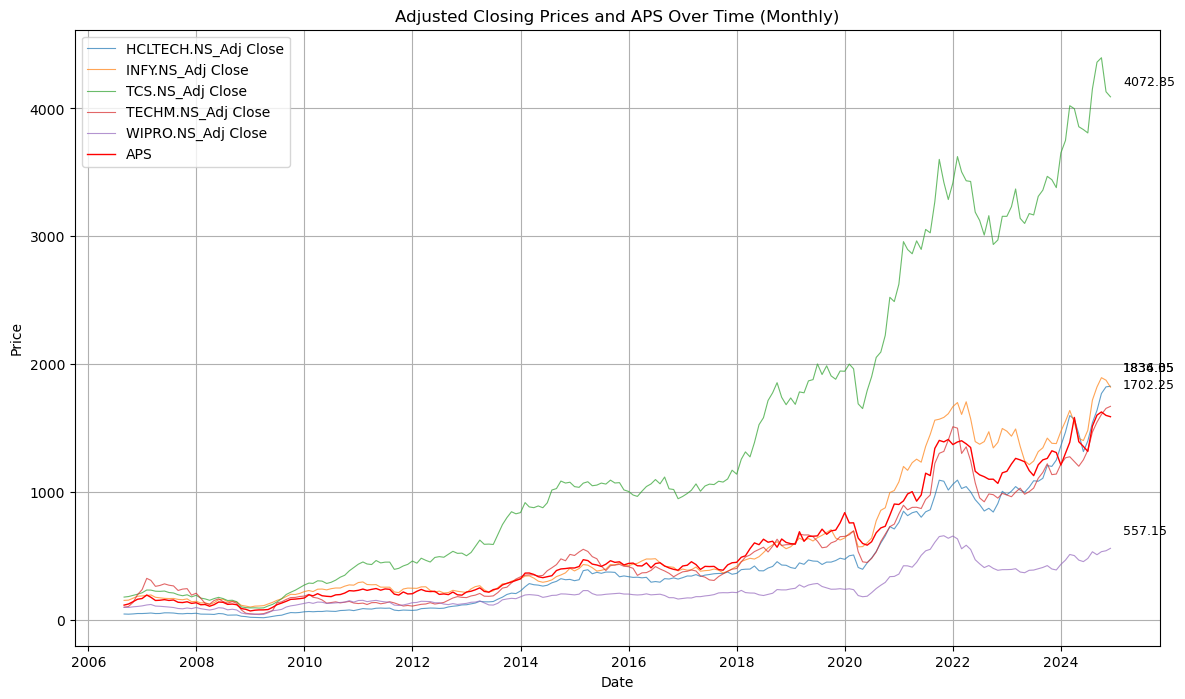

In [20]:
# Resample data to monthly average
data_monthly = valid_data_filled.resample('M').mean()

# Plot the resampled data
plt.figure(figsize=(14, 8))

# Loop through the columns, plotting each one with reduced opacity for others
for col in ['HCLTECH.NS_Adj Close', 'INFY.NS_Adj Close', 'TCS.NS_Adj Close', 'TECHM.NS_Adj Close', 'WIPRO.NS_Adj Close']:
    plt.plot(data_monthly.index, data_monthly[col], label=col, alpha=0.7, linewidth=0.8)

# Plot the APS line with higher opacity and thicker line
plt.plot(data_monthly.index, data_monthly['APS'], label='APS', color='red', alpha=1.0, linewidth=1)

# Set plot title and labels
plt.title('Adjusted Closing Prices and APS Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Price')

# Add legend and grid
plt.legend()
plt.grid()

for stock in it_stocks:
    col = f"{stock}_Adj Close"
    last_price = data[col].iloc[-1]
    last_date = data.index[-1]
    plt.annotate(f'{last_price:.2f}', 
                xy=(last_date, last_price),
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=9)

# Show the plot
plt.show()

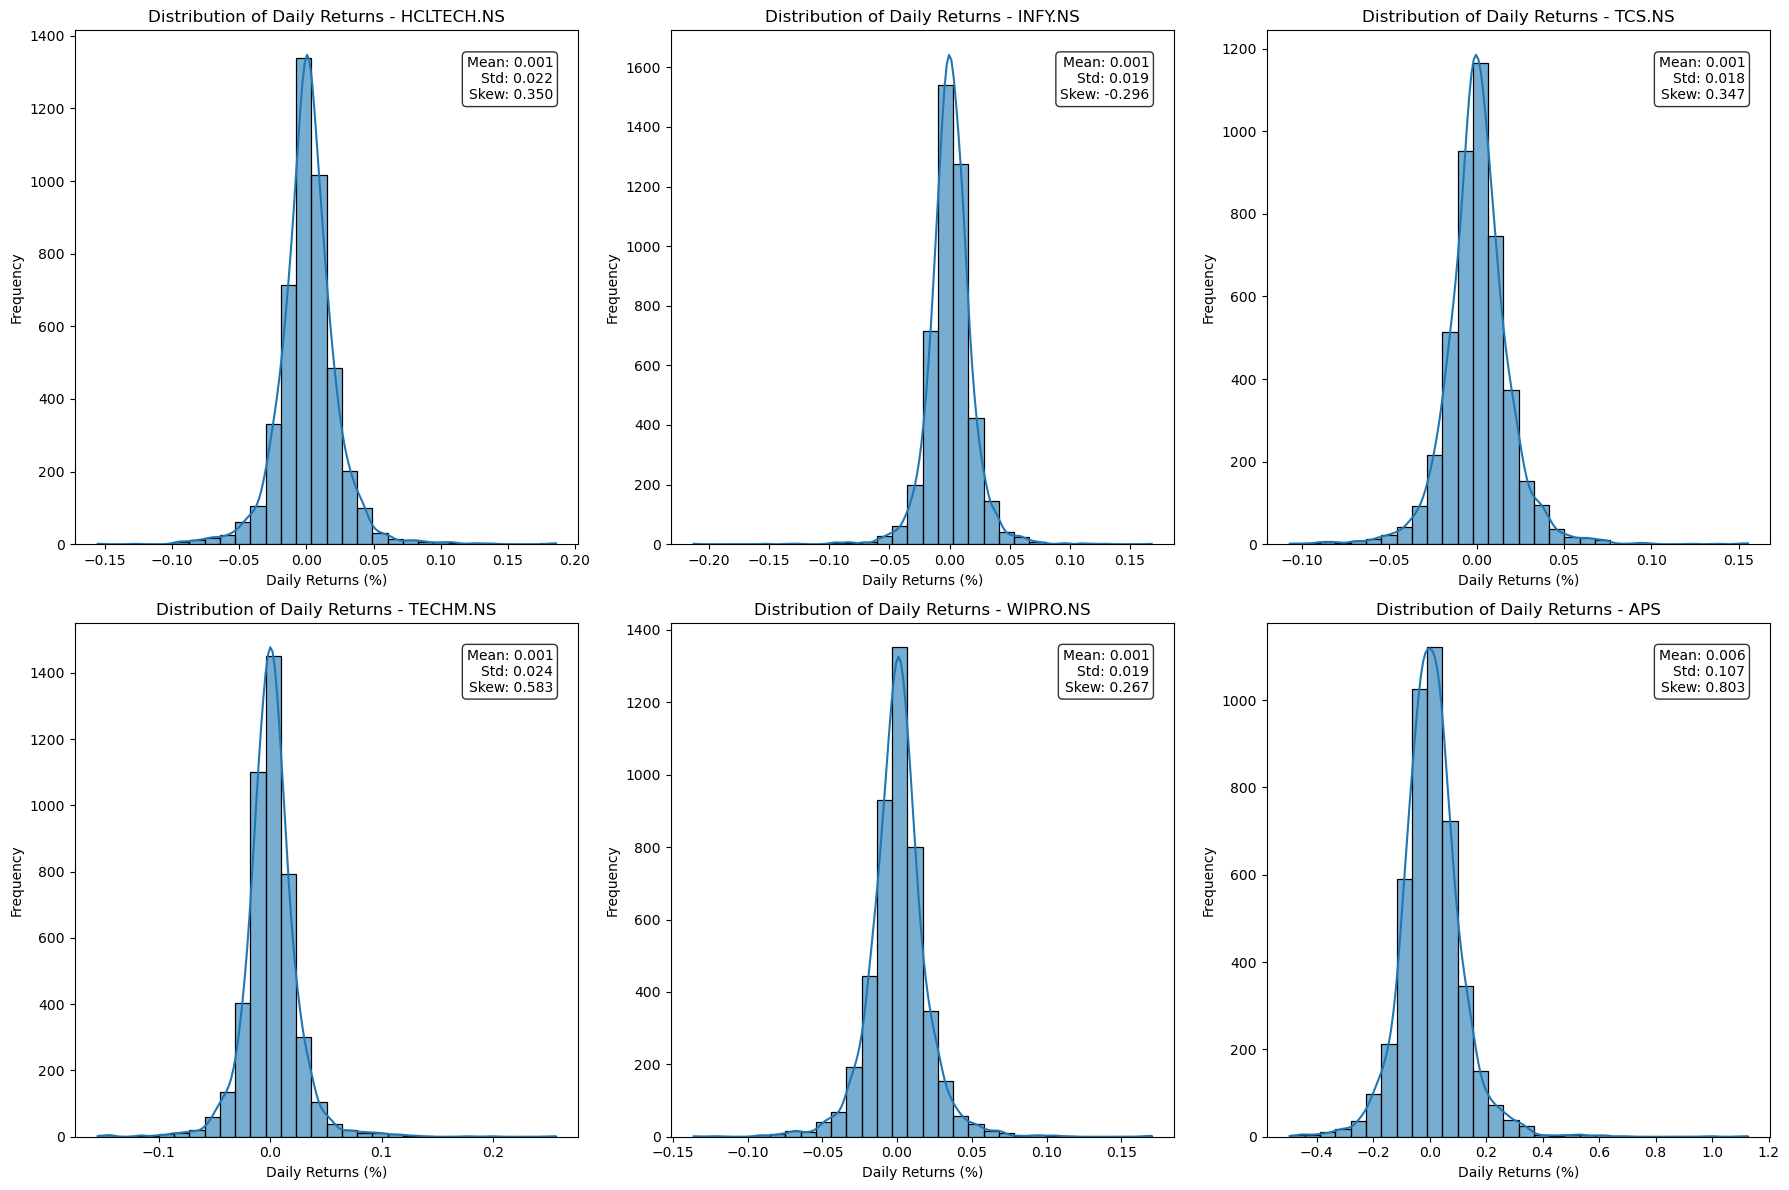

In [22]:
# Calculate returns instead of using raw prices
returns_data = valid_data_filled[columns_to_plot].pct_change()

# Create subplots for returns distributions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Plot each distribution in its own subplot
for i, col in enumerate(columns_to_plot):
    # Plot returns instead of raw prices
    sns.histplot(returns_data[col].dropna(), kde=True, bins=30, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of Daily Returns - {col.replace("_Adj Close", "")}')
    axes[i].set_xlabel('Daily Returns (%)')
    axes[i].set_ylabel('Frequency')
    
    # Add statistical information
    mean_return = returns_data[col].mean()
    std_return = returns_data[col].std()
    skew = returns_data[col].skew()
    
    # Add text box with statistics
    stats_text = f'Mean: {mean_return:.3f}\nStd: {std_return:.3f}\nSkew: {skew:.3f}'
    axes[i].text(0.95, 0.95, stats_text,
                transform=axes[i].transAxes,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [29]:
# Extract the starting and ending prices for HCL and TCS
start_date = '2006-08-28'
end_date = '2024-11-21'

# Get the adjusted close prices for HCL and TCS at the start and end dates
hcl_start_price = valid_data_filled.loc[start_date, 'HCLTECH.NS_Adj Close']
hcl_end_price = valid_data_filled.loc[end_date, 'HCLTECH.NS_Adj Close']

tcs_start_price = valid_data_filled.loc[start_date, 'TCS.NS_Adj Close']
tcs_end_price = valid_data_filled.loc[end_date, 'TCS.NS_Adj Close']

# Calculate the percentage change from start to end for both stocks
hcl_pct_change = ((hcl_end_price - hcl_start_price) / hcl_start_price) * 100
tcs_pct_change = ((tcs_end_price - tcs_start_price) / tcs_start_price) * 100

# Display the results
print(f'HCL Starting Price on {start_date}: {hcl_start_price:.2f}')
print(f'HCL Ending Price on {end_date}: {hcl_end_price:.2f}')
print(f'HCL Percentage Change: {hcl_pct_change:.2f}%\n')

print(f'TCS Starting Price on {start_date}: {tcs_start_price:.2f}')
print(f'TCS Ending Price on {end_date}: {tcs_end_price:.2f}')
print(f'TCS Percentage Change: {tcs_pct_change:.2f}%')


HCL Starting Price on 2006-08-28: 46.53
HCL Ending Price on 2024-11-21: 1836.35
HCL Percentage Change: 3846.24%

TCS Starting Price on 2006-08-28: 177.91
TCS Ending Price on 2024-11-21: 4072.85
TCS Percentage Change: 2189.29%


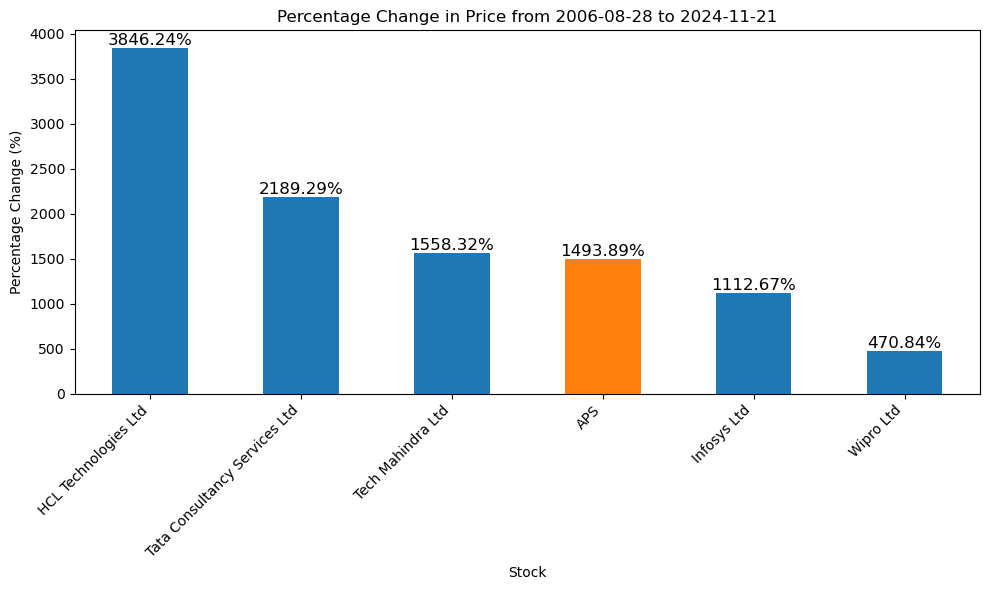

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping from stock ticker symbols to company names (excluding 'APS')
company_name_mapping = {
    'TCS.NS_Adj Close': 'Tata Consultancy Services Ltd',
    'HCLTECH.NS_Adj Close': 'HCL Technologies Ltd',
    'INFY.NS_Adj Close': 'Infosys Ltd',
    'WIPRO.NS_Adj Close': 'Wipro Ltd',
    'TECHM.NS_Adj Close': 'Tech Mahindra Ltd'
}

# Get the starting and ending prices for each stock
start_prices = valid_data_filled[columns_to_plot].iloc[0]  # Price on the first available date
end_prices = valid_data_filled[columns_to_plot].iloc[-1]  # Price on the last available date

# Calculate percentage change from start to end date for each stock
percentage_change_end = ((end_prices - start_prices) / start_prices) * 100

# Clean up the labels to display company names (without '_Adj Close')
company_names = [col.replace('_Adj Close', '') for col in columns_to_plot]

# Sort the percentage change in descending order
percentage_change_end_sorted = percentage_change_end.sort_values(ascending=False)

# Map the sorted ticker symbols to company names (if applicable)
sorted_company_names = [
    company_name_mapping.get(ticker, ticker)  # Map if in mapping, else leave as ticker (for 'APS')
    for ticker in percentage_change_end_sorted.index
]

# Create a bar plot for the percentage change at the end date
plt.figure(figsize=(10, 6))

# Define the colors (use default colors for all, but change APS to a specific color)
colors = ['#1f77b4' if company != 'APS' else '#ff7f0e' for company in sorted_company_names]

# Plotting the bar plot with customized colors
percentage_change_end_sorted.plot(kind='bar', color=colors)

# Set title and labels for the plot
plt.title('Percentage Change in Price from 2006-08-28 to 2024-11-21')
plt.xlabel('Stock')
plt.ylabel('Percentage Change (%)')

# Set x-axis labels to the company names in the order of sorted percentage change
plt.xticks(ticks=np.arange(len(percentage_change_end_sorted)), labels=sorted_company_names, rotation=45, ha='right')

# Display the percentage value on top of the bars
for i, v in enumerate(percentage_change_end_sorted):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()


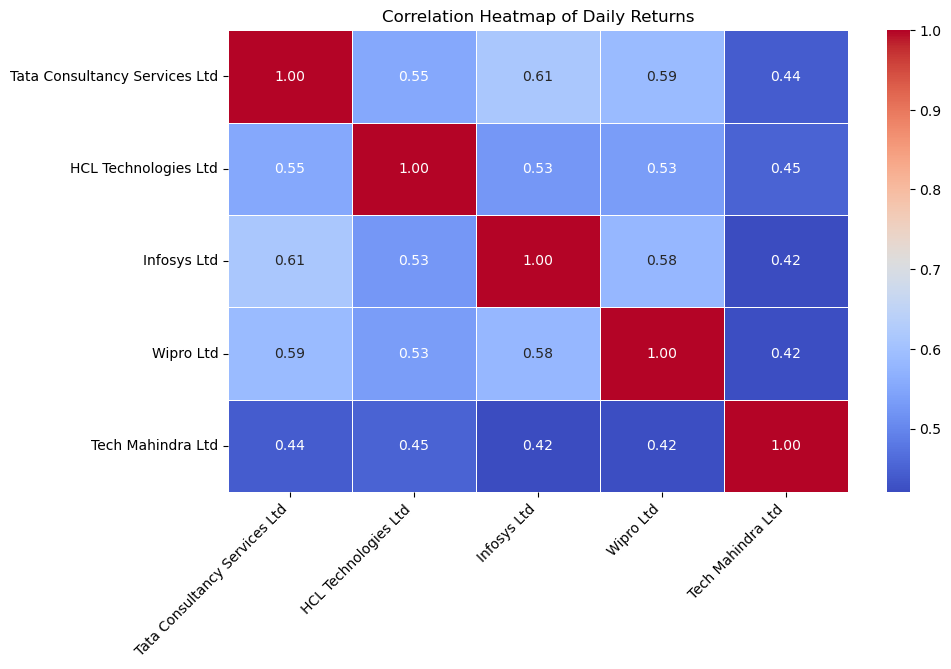

In [55]:
selected_columns = ['TCS.NS_Adj Close', 'HCLTECH.NS_Adj Close', 'INFY.NS_Adj Close', 'WIPRO.NS_Adj Close', 'TECHM.NS_Adj Close']

# Calculate the correlation matrix
correlation_matrix = returns_data[selected_columns].corr()

# Map the tickers to company names
correlation_matrix.columns = [company_name_mapping[col] for col in correlation_matrix.columns]
correlation_matrix.index = [company_name_mapping[col] for col in correlation_matrix.index]

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')

# Set the title and show the plot
plt.title('Correlation Heatmap of Daily Returns')
plt.show()

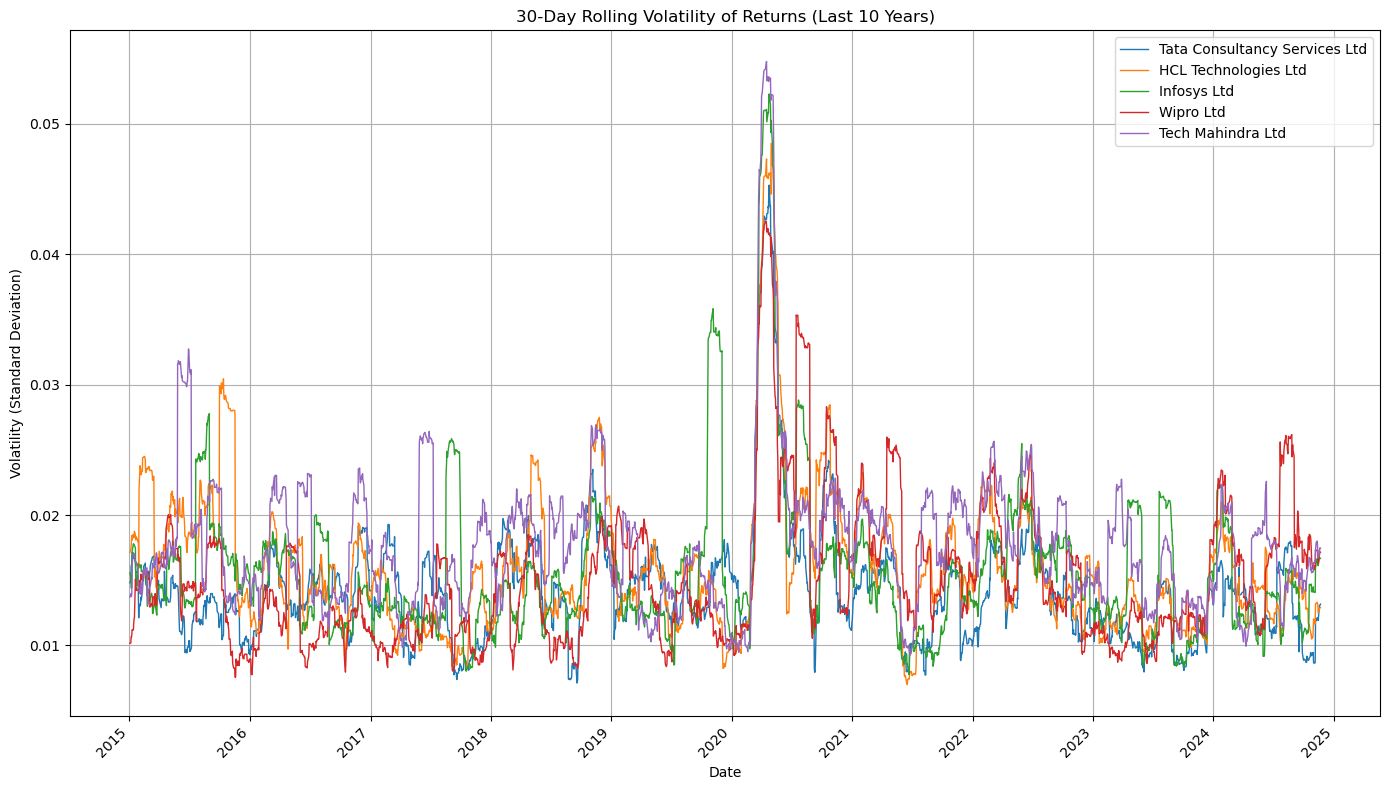

In [58]:
# Limit to the last 10 years
last_decade_start = returns_data.index[-1] - pd.DateOffset(years=10)
recent_returns = returns_data.loc[returns_data.index >= last_decade_start]

# Calculate the 30-day rolling volatility for the selected columns
rolling_volatility = recent_returns[selected_columns].rolling(window=30).std()

# Plot rolling volatility for the last decade
plt.figure(figsize=(14, 8))
for col in selected_columns:
    # Make the line styles more distinct
    plt.plot(rolling_volatility.index, rolling_volatility[col], label=company_name_mapping[col], linewidth=1)

# Set title and labels
plt.title('30-Day Rolling Volatility of Returns (Last 10 Years)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True)

# Rotate x labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()